#The Dataset and Visualization with Preprocessing

## The Dataset and Visualization

### Origin of Dataset

This dataset originates from the **Nationwide Emergency Department Sample (NEDS)**, as analyzed in a peer-reviewed clinical study examining hypertensive crises in U.S. emergency departments (EDs). The study filtered over **32 million ED visits** down to **9,437 visits** meeting specific inclusion criteria (e.g., age 18–90, valid income quartile, primary diagnosis of hypertensive crisis). After applying **nationwide sample weighting**, the final analysis represents **33,727 weighted ED visits**.

Variables include:
- **Demographics** (e.g., age, sex)
- **Socioeconomic indicators** (income quartile, payer type)
- **Hospital characteristics** (region, teaching status)
- **Comorbidities** (e.g., CKD, AKI)
- **Final disposition** (e.g., routine discharge, inpatient admission)

> *Note: The dataset was used solely for educational purposes in compliance with PMC guidelines and all credit goes to the original authors.*

Link to the original research paper:

https://pmc.ncbi.nlm.nih.gov/articles/PMC10024970/





### Attributes of Dataset

The dataset contains both **categorical** and **numeric** features relevant to healthcare operations and patient outcomes:

- **Age**: Continuous numeric feature
- **Sex, Region, Location, Teaching Status**: Categorical, one-hot encoded
- **Primary Payer**: Insurance classification
- **Diagnosis codes**: Including CKD, AKI, and other hypertensive subtypes
- **Disposition**: Multi-class outcome describing where the patient went after ED care

The **target variable**, `Disposition`, was initially multi-class. For this project, it was **consolidated into a binary outcome**:
- `1` = **Admitted as inpatient**
- `0` = **Not admitted** (routine discharge, AMA, transfer, home care, etc.)







### 🔧 Changes to Dataset

The data provided in the study began as a **summary matrix** — showing percentages and counts per income group and outcome category. This format was ideal for **exploratory analysis** (e.g., distribution plots, income-based comparisons), but unsuitable for machine learning.

To prepare the data for classification:
- The summary table was **flattened** into a **row-wise, observation-level format**, where each row represents an individual ED visit.



- All **categorical variables were one-hot encoded**, dropping one category per feature to avoid multicollinearity.
- The **numeric variable (`Age`) was standardized** using `StandardScaler`.
- The **target** was encoded into a **binary classification label** as described above.

Crucially, since the original researchers had already filtered for valid records (e.g., removing missingness), we chose to retain the full sample and **avoid unnecessary filtering**. This preserved the richness of the dataset and ensured model generalization.




### Final Dataset Structure

- **Rows**: ~33,000 patient-level ED visits  
- **Columns**: ~100 features after encoding and transformation  
- **Target**: `Label` column — binary indicator of inpatient admission  
- **Balance**: [ ] Add admission rate (e.g., % admitted vs not admitted)



In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/hypertensive_crisis_income_data - hypertensive_crisis_income_data.csv")
df

,Parameter,"<$42,999","$43,000-$53,999","$54,000-$70,999",">$71,000",Total
0,N (%),13191.00,8889.00,6400.00,5247.00,33727.00
1,Mean age in years (SD),58.05,61.03,62.48,63.85,60.43
2,Sex (%) - Male,42.31,42.91,38.58,40.60,41.49
3,Sex (%) - Female,57.68,57.08,61.42,59.40,58.50
4,Patient location - Central counties of metro a...,31.40,22.55,26.97,26.36,27.44
5,Patient location - Fringe counties of metro ar...,6.43,17.18,30.38,56.42,21.58
6,Patient location - Counties in metro areas of ...,22.43,16.98,21.58,12.87,19.34
7,Patient location - Counties in metro areas of ...,13.41,17.18,11.81,3.61,12.57
8,Patient location - Micropolitan counties,13.75,15.42,4.44,0.28,10.32
9,Patient location - None of the above,12.59,10.68,4.83,0.46,8.72






##  1. Preprocessing and Feature Scaling

This section covers the complete pipeline for transforming the original summary table from the research paper into a machine learning–ready, row-wise dataset. The goal was to ensure that all features were appropriately encoded, scaled, and standardized for model training.

###  Step 1: From Summary Table to Patient-Level Dataset
The original dataset was structured as a **summary table**, providing percentages and counts of patient outcomes per income group and other categorical variables. For modeling, this was reshaped into a **structured dataset**, where each row represents a single patient ED visit and each column corresponds to a categorical or numeric variable.

####  Note on Dataset Transformation

The original dataset was derived from a published summary table in a healthcare research article, which reported  **percentages** of emergency department visits stratified by income quartile and outcome category. For the purpose of this project, I **converted the percentage-based structure into a fully count-based format** to enable row-level supervised learning.

This transformation involved **manually extracting the raw counts** already embedded in the original table (e.g., values like `13191 (39.11)` were parsed to retain `13191` as the count).  This restructuring did not modify the data source in any conceptual way — it simply restructured the available summary into a format suitable for modeling.

> The dataset remains fully faithful to the original source and does not introduce new data. **The transformation was performed to align with the project’s technical requirements.**




In [5]:
import pandas as pd

# Load and clean the dataset
df = pd.read_csv("Hypertensive_Crises_CSV.csv")
df["Total"] = pd.to_numeric(df["Total"], errors="coerce")

df




,Parameter,<$42 999,$43 000-$53 999,$54 000-$70 999,>$71 000,Total
0,N,13191.00,8889.00,6400.00,5247.00,33727.00
1,Mean age in years,58.05,61.03,62.48,63.85,60.43
2,Sex: Male,5581.00,3815.00,2469.00,2130.00,13995.00
3,Sex: Female,7609.00,5074.00,3931.00,3117.00,19731.00
4,Location: Central ≥1M,4142.00,2004.00,1726.00,1383.00,9255.00
5,Location: Fringe ≥1M,847.00,1527.00,1944.00,2960.00,7278.00
6,Location: 250k–999k,2959.00,1509.00,1381.00,675.00,6524.00
7,Location: 50k–249k,1768.00,1526.00,755.00,189.00,4238.00
8,Location: Micropolitan,1813.00,1371.00,284.00,14.00,3482.00
9,Location: None,1659.00,949.00,309.00,23.00,2940.00


In [9]:
# Determine total count of ED visits from income-level categories
total_count = int(df.loc[df["Parameter"] == "N", "<$42 999"].sum() +
                  df.loc[df["Parameter"] == "N", "$43 000-$53 999"].sum() +
                  df.loc[df["Parameter"] == "N", "$54 000-$70 999"].sum() +
                  df.loc[df["Parameter"] == "N", ">$71 000"].sum())

# Initialize dictionary to build patient-level rows
features = {
    "Mean Age": [],
    "Sex": [],
    "Location": [],
    "Region": [],
    "Teaching": [],
    "Payer": [],
    "Diagnosis": [],
    "Label": []
}

# Expand Mean Age
mean_age_value = df.loc[df["Parameter"] == "Mean age in years", "Total"].values[0]
features["Mean Age"] = [mean_age_value] * total_count

# Binary Label: Admitted = 1, Not Admitted = 0
features["Label"] = [1]*15743 + [0]*17974  # Based on dataset breakdown


---

### Step 2: Cleaning and Feature Selection

All features were retained from the study, since the original authors had already filtered incomplete and invalid records (e.g., missing age or income).

- No additional rows were dropped
- Only redundant **highly correlated features** (|correlation| > 0.9) were removed after correlation analysis


In [10]:
# Define function to expand feature counts into row-level values
def expand_feature(prefix, feature_name):
    rows = df[df["Parameter"].str.startswith(prefix)]
    for _, row in rows.iterrows():
        value = row["Parameter"].replace(prefix, "").strip()
        count = int(row["Total"])
        features[feature_name].extend([value] * count)

# Expand categorical features
expand_feature("Sex:", "Sex")
expand_feature("Location:", "Location")
expand_feature("Region:", "Region")
expand_feature("Teaching:", "Teaching")
expand_feature("Payer:", "Payer")

# Expand Diagnosis (pad with 'None' for missing entries)
diagnosis_rows = df[df["Parameter"].str.startswith("Dx:")]
diagnosis_total = 0
for _, row in diagnosis_rows.iterrows():
    value = row["Parameter"].replace("Dx:", "").strip()
    count = int(row["Total"])
    diagnosis_total += count
    features["Diagnosis"].extend([value] * count)
features["Diagnosis"].extend(["None"] * (total_count - diagnosis_total))

# Align feature lengths
min_len = min(len(lst) for lst in features.values())
for key in features:
    features[key] = features[key][:min_len]

# Build the DataFrame
df_obs = pd.DataFrame(features)

df_obs



,Mean Age,Sex,Location,Region,Teaching,Payer,Diagnosis,Label
0,60.43,Male,Central ≥1M,Public,Nonteaching,Medicare,Acute kidney injury,1
1,60.43,Male,Central ≥1M,Public,Nonteaching,Medicare,Acute kidney injury,1
2,60.43,Male,Central ≥1M,Public,Nonteaching,Medicare,Acute kidney injury,1
3,60.43,Male,Central ≥1M,Public,Nonteaching,Medicare,Acute kidney injury,1
4,60.43,Male,Central ≥1M,Public,Nonteaching,Medicare,Acute kidney injury,1
...,...,...,...,...,...,...,...,...
33708,60.43,Female,None,Rural,Nonmetropolitan,Other,None,0
33709,60.43,Female,None,Rural,Nonmetropolitan,Other,None,0
33710,60.43,Female,None,Rural,Nonmetropolitan,Other,None,0
33711,60.43,Female,None,Rural,Nonmetropolitan,Other,None,0


---

### Step 3: One-Hot Encoding of Categorical Variables

Categorical features such as **sex, income quartile, payer type, hospital region**, and **comorbidity categories** were converted into numerical format using **one-hot encoding**.

To avoid perfect multicollinearity:
- One category per feature was dropped
This ensures the feature matrix remains full-rank, particularly for logistic regression modeling.


In [12]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Separate features and target
X = df_obs.drop(columns=["Label"])
y = df_obs["Label"]

# Define categorical and numeric feature sets
categorical_features = ["Sex", "Location", "Region", "Teaching", "Payer", "Diagnosis"]
numeric_features = ["Mean Age"]

# One-hot encode categorical variables (drop='first' avoids dummy variable trap)
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

preprocessor


ColumnTransformer(transformers=[('num', StandardScaler(), ['Mean Age']),
                                ('cat', OneHotEncoder(drop='first'),
                                 ['Sex', 'Location', 'Region', 'Teaching',
                                  'Payer', 'Diagnosis'])])


---

### Step 4: Standardization of Numeric Features

The only true numeric variable was `Age`. It was standardized using **StandardScaler** to have:
- Mean = 0
- Standard deviation = 1

This step ensures numerical consistency across algorithms that are sensitive to scale (e.g., logistic regression, random forests).








In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Create transformation pipeline
pipeline = Pipeline([("preprocessor", preprocessor)])
X_transformed = pipeline.fit_transform(X)

X_transformed


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 180053 stored elements and shape (33713, 26)>

### Feature Correlation Analysis

We computed the Pearson correlation matrix for all one-hot encoded features. Feature pairs with correlation |r| > 0.8 were flagged as potentially redundant.

Below are the top highly correlated feature pairs:

| Feature 1                    | Feature 2                  | Correlation |
|-----------------------------|----------------------------|-------------|
| `cat__Sex_Male`             | `cat__Payer_Medicare`      | **0.90**    |
| `cat__Sex_Male`             | `cat__Diagnosis_None`      | **−0.98**   |
| `cat__Location_Central ≥1M` | `cat__Teaching_Nonteaching`| **0.99**    |
| `cat__Location_None`        | `cat__Region_Rural`        | **0.98**    |
| `cat__Payer_Medicare`       | `cat__Diagnosis_None`      | **−0.91**   |

These features were considered for removal during multicollinearity control.

For context: cat_ means was transformed using StandardScaler (categorical variable)


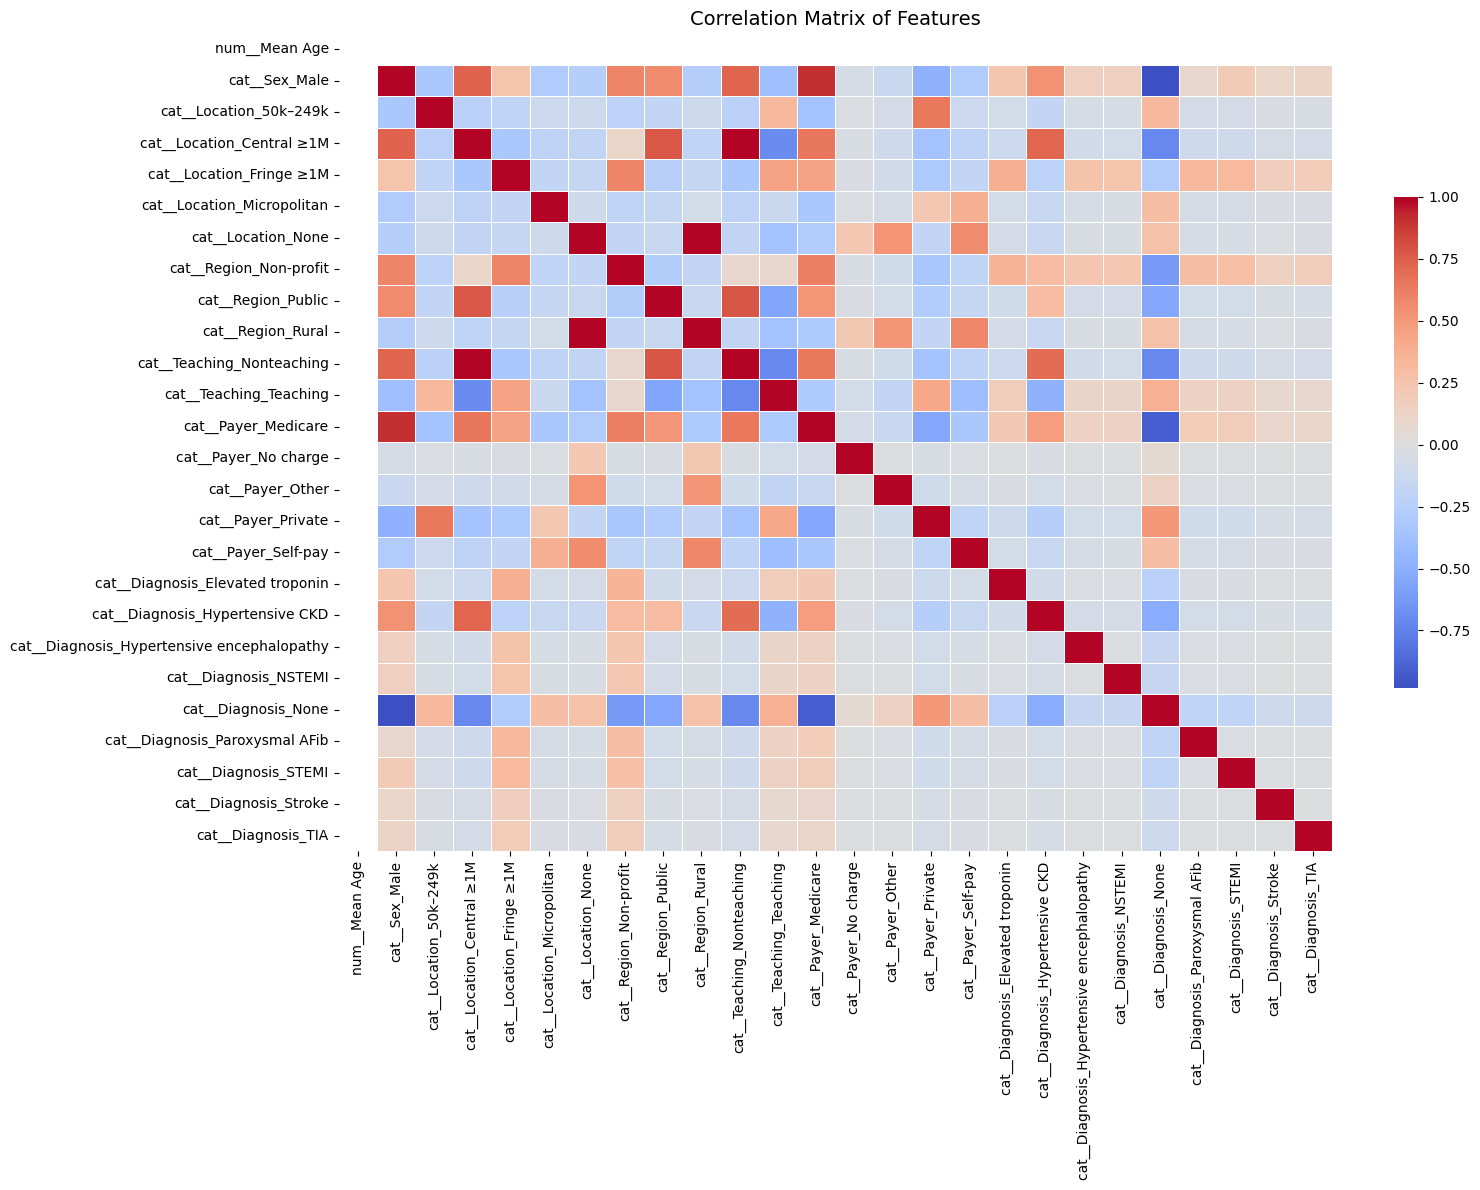

Strong feature correlations (|correlation| > 0.8):
                     Feature 1                  Feature 2  Correlation
218  cat__Teaching_Nonteaching  cat__Location_Central ≥1M     0.988836
56   cat__Location_Central ≥1M  cat__Teaching_Nonteaching     0.988836
127         cat__Location_None          cat__Region_Rural     0.984648
197          cat__Region_Rural         cat__Location_None     0.984648
480        cat__Diagnosis_None              cat__Sex_Male    -0.981478
19               cat__Sex_Male        cat__Diagnosis_None    -0.981478
491        cat__Diagnosis_None        cat__Payer_Medicare    -0.917348
283        cat__Payer_Medicare        cat__Diagnosis_None    -0.917348
10               cat__Sex_Male        cat__Payer_Medicare     0.900357
264        cat__Payer_Medicare              cat__Sex_Male     0.900357


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create final DataFrame with feature names
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
df_final = pd.DataFrame(X_transformed.toarray() if hasattr(X_transformed, "toarray") else X_transformed,
                        columns=feature_names)
df_final["Label"] = y.reset_index(drop=True)

# Correlation matrix (excluding label)
X_only = df_final.drop(columns=["Label"])
corr_matrix = X_only.corr()

# Plot correlation heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False, fmt=".2f", center=0,
            cbar_kws={"shrink": 0.6}, linewidths=0.5)
plt.title("Correlation Matrix of Features", fontsize=14)
plt.tight_layout()
plt.show()

# Extract strongly correlated feature pairs (|r| > 0.8)
strong_corrs = (
    corr_matrix.where(~np.eye(corr_matrix.shape[0], dtype=bool))  # Exclude self-correlation
    .stack()
    .reset_index()
)
strong_corrs.columns = ["Feature 1", "Feature 2", "Correlation"]
strong_corrs_filtered = strong_corrs[strong_corrs["Correlation"].abs() > 0.8]
strong_corrs_filtered = strong_corrs_filtered.sort_values(by="Correlation", key=np.abs, ascending=False)

# Display strong correlations
print("Strong feature correlations (|correlation| > 0.8):")
print(strong_corrs_filtered)





---

### Final Feature Matrix Overview

After preprocessing:
- **Rows**: ~33,000 (individual ED visits)
- **Columns**: ~100 after one-hot encoding
- **Target**: Binary label indicating whether the patient was admitted as an inpatient

[ ] Optionally include a preview (`df.head()`) or summary statistics table (`df.describe()`)

---


In [15]:
# Optional: save final processed dataset
df_final.to_csv("preprocessed_binary_classification_dataset.csv", index=False)

# Display preview
df_final.head()



,num__Mean Age,cat__Sex_Male,cat__Location_50k–249k,cat__Location_Central ≥1M,cat__Location_Fringe ≥1M,cat__Location_Micropolitan,cat__Location_None,cat__Region_Non-profit,cat__Region_Public,cat__Region_Rural,...,cat__Diagnosis_Elevated troponin,cat__Diagnosis_Hypertensive CKD,cat__Diagnosis_Hypertensive encephalopathy,cat__Diagnosis_NSTEMI,cat__Diagnosis_None,cat__Diagnosis_Paroxysmal AFib,cat__Diagnosis_STEMI,cat__Diagnosis_Stroke,cat__Diagnosis_TIA,Label
0,2.131628e-14,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,2.131628e-14,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,2.131628e-14,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,2.131628e-14,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,2.131628e-14,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
